In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import keras, datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from src.models.assemble_model import build_predict_model
from src.miscellaneous import create_seq_dataset_multiple_input_single_output
from sklearn.utils import class_weight
from sklearn.preprocessing import OneHotEncoder
from src.models.layer import DecompositionLayer, FeatureWiseScalingLayer, gelu_approximate
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

In [2]:
root_path = 'data/on-road_test_15meter_1'
file_name_list = os.listdir(root_path)

In [3]:
train_data_file_name_list = [file_name_list[0]]+file_name_list[2:]

data_df_list = []

for file_name in train_data_file_name_list:
    file_path = os.path.join(root_path, file_name)
    data = pd.read_csv(file_path)

    data = data.iloc[:, 1:]
    data = data[data['boom_length(m)'] >1]
    data.reset_index(drop=True, inplace=True)

    data_df_list.append(data)

train_data = pd.concat(data_df_list)
train_data.reset_index(drop=True, inplace=True)
train_data

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,load_cell_left_2,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,load_ratio,roll_over_state,pred,detection
0,0.201,15.054,30.229,3.341,748.0,-0.598,258.0,-0.24,0.25,1.030,0.030,0.00,34.454,0.000,1.160,0.03414,1,0.99994,1
1,0.301,15.054,30.229,3.341,748.0,-0.598,258.0,-0.24,0.25,1.030,0.030,0.00,34.454,0.000,1.160,0.03414,1,0.99993,1
2,0.401,15.054,30.229,3.341,748.0,-0.598,258.0,-0.25,0.25,1.030,0.030,0.00,34.454,0.000,1.160,0.03414,1,0.99984,1
3,0.501,15.046,30.224,3.372,748.0,-0.598,258.0,-0.25,0.25,1.030,0.020,0.00,34.454,0.000,1.160,0.03414,1,0.99958,1
4,0.601,15.046,30.224,3.372,748.0,-0.598,258.0,-0.25,0.24,1.030,0.020,0.00,34.454,0.000,1.160,0.03414,1,0.98867,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14593,558.641,15.003,29.850,5.125,748.0,-0.598,258.0,-0.25,0.25,2.573,2.573,3.41,21.061,2.573,20.306,0.96771,0,0.00001,0
14594,558.741,15.052,29.725,5.125,748.0,-0.598,258.0,-0.24,0.25,2.573,2.573,3.41,21.061,2.573,20.306,0.96771,0,0.00001,0
14595,558.841,15.052,29.725,5.125,748.0,-0.598,258.0,-0.24,0.25,2.573,2.573,3.41,21.061,2.573,20.306,0.96771,0,0.00001,0
14596,558.941,15.052,29.725,5.125,748.0,-0.598,258.0,-0.24,0.25,2.573,2.573,3.41,21.061,2.573,20.306,0.96771,0,0.00000,0


In [4]:
val_data_file_name_list = [file_name_list[1]]

data_df_list = []

for file_name in val_data_file_name_list:
    file_path = os.path.join(root_path, file_name)
    data = pd.read_csv(file_path)

    data = data.iloc[:, 1:]
    data = data[data['boom_length(m)'] >1]
    data.reset_index(drop=True, inplace=True)

    data_df_list.append(data)

val_data = pd.concat(data_df_list)
val_data.reset_index(drop=True, inplace=True)
val_data

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,load_cell_left_2,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,load_ratio,roll_over_state,pred,detection
0,0.100,15.056,29.475,5.338,748.0,-0.598,258.0,-0.24,0.26,3.410,20.306,21.074,3.338,3.410,17.674,0.29871,1,0.99996,0
1,0.201,15.048,29.475,5.338,748.0,-0.598,258.0,-0.24,0.26,3.410,20.306,21.074,3.338,3.410,17.674,0.29871,1,0.99995,0
2,0.301,15.048,29.475,5.338,748.0,-0.598,258.0,-0.24,0.26,3.410,20.306,21.074,3.338,3.410,17.674,0.29871,1,0.99991,0
3,0.401,15.048,29.475,5.338,748.0,-0.598,258.0,-0.24,0.26,3.410,20.306,21.074,3.338,3.410,17.674,0.29871,1,0.99980,0
4,0.504,15.048,29.475,5.338,748.0,-0.598,258.0,-0.24,0.25,3.410,20.306,21.074,3.338,3.410,17.674,0.29871,1,0.99809,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3872,388.860,15.046,29.975,6.062,752.0,-0.598,258.0,-0.24,0.25,17.674,3.338,2.573,21.074,17.674,21.071,0.99986,0,0.00001,0
3873,388.961,15.046,29.975,6.062,752.0,-0.598,258.0,-0.23,0.26,17.674,3.338,2.573,21.074,17.674,21.071,0.99986,0,0.00001,0
3874,389.061,15.046,29.975,6.075,748.0,-0.598,258.0,-0.23,0.26,17.674,3.338,2.573,21.074,17.674,21.071,0.99986,0,0.00001,0
3875,389.161,15.033,29.975,6.044,748.0,-0.598,258.0,-0.23,0.26,17.674,3.338,2.573,21.074,17.674,21.071,0.99986,0,0.00001,0


In [5]:
ref_working_distance_arr = [4.5, 5.0, 5.5, 6.0, 7.0, 8.0, 9.0, 10.0, 12.0, 14.0, 16.0]
ref_working_distance_arr = np.array(ref_working_distance_arr)

ref_load_capacity_arr = [150.0, 135.2, 123.4, 113.5, 97.7, 85.6, 73.4, 62.8, 48.4, 39.1, 37.3]
ref_load_capacity_arr = np.array(ref_load_capacity_arr)

print(f'ref data integrity: {len(ref_working_distance_arr) == len(ref_load_capacity_arr)}')

ref data integrity: True


In [6]:
boom_length = 15
working_distance_arr = np.cos(np.deg2rad(train_data['boom_angle(deg)'].to_numpy()))*boom_length
current_load_capacity = np.interp(working_distance_arr, ref_working_distance_arr, ref_load_capacity_arr)
load_usage_arr = (train_data['load_weight(ton)'].to_numpy() / current_load_capacity) * 100
train_data['load_usage'] = load_usage_arr

train_data

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,load_cell_left_2,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,load_ratio,roll_over_state,pred,detection,load_usage
0,0.201,15.054,30.229,3.341,748.0,-0.598,258.0,-0.24,0.25,1.030,0.030,0.00,34.454,0.000,1.160,0.03414,1,0.99994,1,7.604485
1,0.301,15.054,30.229,3.341,748.0,-0.598,258.0,-0.24,0.25,1.030,0.030,0.00,34.454,0.000,1.160,0.03414,1,0.99993,1,7.604485
2,0.401,15.054,30.229,3.341,748.0,-0.598,258.0,-0.25,0.25,1.030,0.030,0.00,34.454,0.000,1.160,0.03414,1,0.99984,1,7.604485
3,0.501,15.046,30.224,3.372,748.0,-0.598,258.0,-0.25,0.25,1.030,0.020,0.00,34.454,0.000,1.160,0.03414,1,0.99958,1,7.675580
4,0.601,15.046,30.224,3.372,748.0,-0.598,258.0,-0.25,0.24,1.030,0.020,0.00,34.454,0.000,1.160,0.03414,1,0.98867,1,7.675580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14593,558.641,15.003,29.850,5.125,748.0,-0.598,258.0,-0.25,0.25,2.573,2.573,3.41,21.061,2.573,20.306,0.96771,0,0.00001,0,11.726714
14594,558.741,15.052,29.725,5.125,748.0,-0.598,258.0,-0.24,0.25,2.573,2.573,3.41,21.061,2.573,20.306,0.96771,0,0.00001,0,11.747033
14595,558.841,15.052,29.725,5.125,748.0,-0.598,258.0,-0.24,0.25,2.573,2.573,3.41,21.061,2.573,20.306,0.96771,0,0.00001,0,11.747033
14596,558.941,15.052,29.725,5.125,748.0,-0.598,258.0,-0.24,0.25,2.573,2.573,3.41,21.061,2.573,20.306,0.96771,0,0.00000,0,11.747033


<Axes: xlabel='boom_angle(deg)', ylabel='load_usage'>

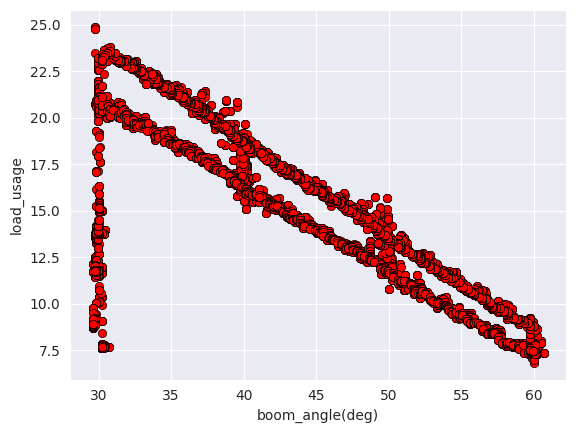

In [7]:
sns.scatterplot(data=train_data, x='boom_angle(deg)', y='load_usage', color='red', edgecolor='black')

In [8]:
boom_length = 15
working_distance_arr = np.cos(np.deg2rad(val_data['boom_angle(deg)'].to_numpy()))*boom_length
current_load_capacity = np.interp(working_distance_arr, ref_working_distance_arr, ref_load_capacity_arr)
load_usage_arr = (val_data['load_weight(ton)'].to_numpy() / current_load_capacity) * 100
val_data['load_usage'] = load_usage_arr

val_data

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,load_cell_left_2,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,load_ratio,roll_over_state,pred,detection,load_usage
0,0.100,15.056,29.475,5.338,748.0,-0.598,258.0,-0.24,0.26,3.410,20.306,21.074,3.338,3.410,17.674,0.29871,1,0.99996,0,12.277556
1,0.201,15.048,29.475,5.338,748.0,-0.598,258.0,-0.24,0.26,3.410,20.306,21.074,3.338,3.410,17.674,0.29871,1,0.99995,0,12.277556
2,0.301,15.048,29.475,5.338,748.0,-0.598,258.0,-0.24,0.26,3.410,20.306,21.074,3.338,3.410,17.674,0.29871,1,0.99991,0,12.277556
3,0.401,15.048,29.475,5.338,748.0,-0.598,258.0,-0.24,0.26,3.410,20.306,21.074,3.338,3.410,17.674,0.29871,1,0.99980,0,12.277556
4,0.504,15.048,29.475,5.338,748.0,-0.598,258.0,-0.24,0.25,3.410,20.306,21.074,3.338,3.410,17.674,0.29871,1,0.99809,0,12.277556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3872,388.860,15.046,29.975,6.062,752.0,-0.598,258.0,-0.24,0.25,17.674,3.338,2.573,21.074,17.674,21.071,0.99986,0,0.00001,0,13.846658
3873,388.961,15.046,29.975,6.062,752.0,-0.598,258.0,-0.23,0.26,17.674,3.338,2.573,21.074,17.674,21.071,0.99986,0,0.00001,0,13.846658
3874,389.061,15.046,29.975,6.075,748.0,-0.598,258.0,-0.23,0.26,17.674,3.338,2.573,21.074,17.674,21.071,0.99986,0,0.00001,0,13.876352
3875,389.161,15.033,29.975,6.044,748.0,-0.598,258.0,-0.23,0.26,17.674,3.338,2.573,21.074,17.674,21.071,0.99986,0,0.00001,0,13.805543


<Axes: xlabel='boom_angle(deg)', ylabel='load_usage'>

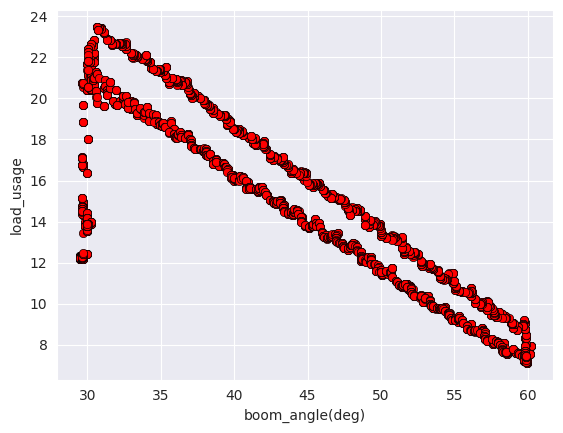

In [9]:
sns.scatterplot(data=val_data, x='boom_angle(deg)', y='load_usage', color='red', edgecolor='black')

In [10]:
feature_name_list = ['boom_angle(deg)', 'load_weight(ton)', 'engine_speed(rpm)', 'body_angle_x(deg)', 'body_angle_y(deg)']
target_name = 'load_usage'

train_dataset_arr = train_data[feature_name_list + [target_name]].to_numpy()
train_dataset_arr

array([[ 3.02290000e+01,  3.34100000e+00,  7.48000000e+02,
        -2.40000000e-01,  2.50000000e-01,  7.60448507e+00],
       [ 3.02290000e+01,  3.34100000e+00,  7.48000000e+02,
        -2.40000000e-01,  2.50000000e-01,  7.60448507e+00],
       [ 3.02290000e+01,  3.34100000e+00,  7.48000000e+02,
        -2.50000000e-01,  2.50000000e-01,  7.60448507e+00],
       ...,
       [ 2.97250000e+01,  5.12500000e+00,  7.48000000e+02,
        -2.40000000e-01,  2.50000000e-01,  1.17470334e+01],
       [ 2.97250000e+01,  5.12500000e+00,  7.48000000e+02,
        -2.40000000e-01,  2.50000000e-01,  1.17470334e+01],
       [ 2.97250000e+01,  5.12500000e+00,  7.48000000e+02,
        -2.40000000e-01,  2.60000000e-01,  1.17470334e+01]],
      shape=(14598, 6))

In [11]:
val_dataset_arr = val_data[feature_name_list + [target_name]].to_numpy()
val_dataset_arr

array([[ 2.94750000e+01,  5.33800000e+00,  7.48000000e+02,
        -2.40000000e-01,  2.60000000e-01,  1.22775557e+01],
       [ 2.94750000e+01,  5.33800000e+00,  7.48000000e+02,
        -2.40000000e-01,  2.60000000e-01,  1.22775557e+01],
       [ 2.94750000e+01,  5.33800000e+00,  7.48000000e+02,
        -2.40000000e-01,  2.60000000e-01,  1.22775557e+01],
       ...,
       [ 2.99750000e+01,  6.07500000e+00,  7.48000000e+02,
        -2.30000000e-01,  2.60000000e-01,  1.38763523e+01],
       [ 2.99750000e+01,  6.04400000e+00,  7.48000000e+02,
        -2.30000000e-01,  2.60000000e-01,  1.38055430e+01],
       [ 2.99750000e+01,  6.07500000e+00,  7.48000000e+02,
        -2.30000000e-01,  2.50000000e-01,  1.38763523e+01]],
      shape=(3877, 6))

In [12]:
threshold_usage = 20

train_feature_arr = train_dataset_arr[:, 0:5]
train_target_arr = (train_dataset_arr[:, 5] > threshold_usage).astype(int)
train_dataset_arr = np.concatenate([train_feature_arr, train_target_arr.reshape(-1, 1)], axis=1)

val_feature_arr = val_dataset_arr[:, 0:5]
val_target_arr = (val_dataset_arr[:, 5] > threshold_usage).astype(int)
val_dataset_arr = np.concatenate([val_feature_arr, val_target_arr.reshape(-1, 1)], axis=1)

In [13]:
train_dataset_arr

array([[ 3.0229e+01,  3.3410e+00,  7.4800e+02, -2.4000e-01,  2.5000e-01,
         0.0000e+00],
       [ 3.0229e+01,  3.3410e+00,  7.4800e+02, -2.4000e-01,  2.5000e-01,
         0.0000e+00],
       [ 3.0229e+01,  3.3410e+00,  7.4800e+02, -2.5000e-01,  2.5000e-01,
         0.0000e+00],
       ...,
       [ 2.9725e+01,  5.1250e+00,  7.4800e+02, -2.4000e-01,  2.5000e-01,
         0.0000e+00],
       [ 2.9725e+01,  5.1250e+00,  7.4800e+02, -2.4000e-01,  2.5000e-01,
         0.0000e+00],
       [ 2.9725e+01,  5.1250e+00,  7.4800e+02, -2.4000e-01,  2.6000e-01,
         0.0000e+00]], shape=(14598, 6))

<Axes: ylabel='Count'>

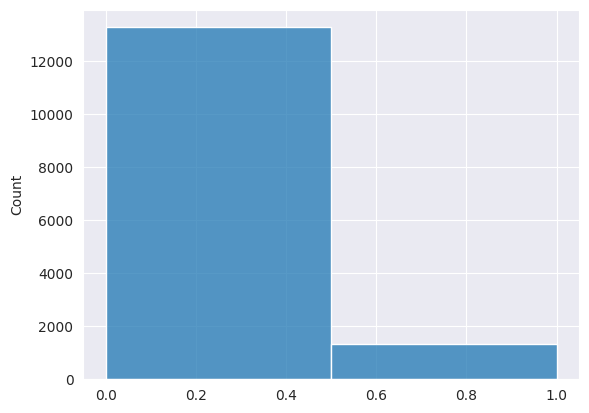

In [14]:
sns.histplot(train_dataset_arr[:, 5], bins=2)

<Axes: ylabel='Count'>

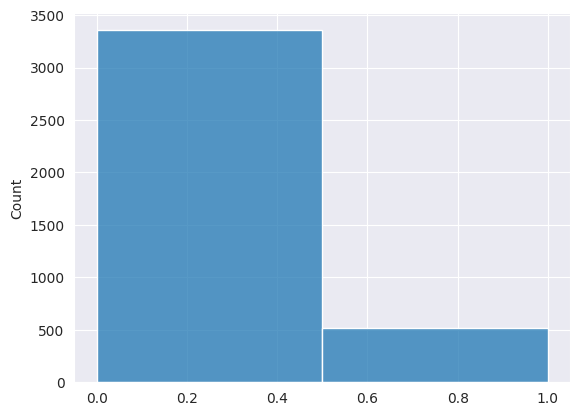

In [15]:
sns.histplot(val_dataset_arr[:, 5], bins=2)

In [16]:
seq_len = 50
pred_distance = 30

train_feature, train_target = create_seq_dataset_multiple_input_single_output(train_dataset_arr,
                                                                                  seq_len=seq_len,
                                                                                  pred_distance=pred_distance,
                                                                                  target_idx_pos=train_dataset_arr.shape[1]-1)

train_target = np.squeeze(train_target)
print(train_feature.shape, train_target.shape)

creating sequence dataset...:   0%|          | 0/14568 [00:00<?, ?it/s]

(14519, 50, 5) (14519,)


In [17]:
# train_feature_2, train_target_2 = create_seq_dataset_multiple_input_single_output(train_dataset_arr,
#                                                                                   seq_len=seq_len,
#                                                                                   pred_distance=0,
#                                                                                   target_idx_pos=train_dataset_arr.shape[1]-1)
#
# train_target_2 = np.squeeze(train_target_2)
# train_target_2 = train_target_2*2
# print(train_feature_2.shape, train_target_2.shape)

In [18]:
#train_feature = np.concatenate([train_feature_1, train_feature_2], axis=0)
#train_target = np.concatenate([train_target_1, train_target_2], axis=0)
# print(train_feature.shape, train_target.shape)

# This works if train_target contains integer labels
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(train_target), y=train_target)

class_weight_dict = dict(enumerate(weights))

class_weight_dict

{0: np.float64(0.5501705191360364), 1: np.float64(5.483006042296073)}

In [19]:
onehot_enc = OneHotEncoder()
train_target_onehot = onehot_enc.fit_transform(train_target.reshape(-1, 1)).toarray()

print(train_target_onehot)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [20]:
val_feature, val_target = create_seq_dataset_multiple_input_single_output(val_dataset_arr,
                                                                              seq_len=seq_len,
                                                                              pred_distance=pred_distance,
                                                                              target_idx_pos=val_dataset_arr.shape[1]-1)

val_target = np.squeeze(val_target)
print(val_feature.shape, val_target.shape)

creating sequence dataset...:   0%|          | 0/3847 [00:00<?, ?it/s]

(3798, 50, 5) (3798,)


In [21]:
# val_feature_2, val_target_2 = create_seq_dataset_multiple_input_single_output(val_dataset_arr,
#                                                                               seq_len=seq_len,
#                                                                               pred_distance=0,
#                                                                               target_idx_pos=val_dataset_arr.shape[1]-1)
#
# val_target_2 = np.squeeze(val_target_2)*2
# print(val_feature_2.shape, val_target_2.shape)

In [22]:
# val_feature = np.concatenate([val_feature_1, val_feature_2], axis=0)
# val_target = np.concatenate([val_target_1, val_target_2], axis=0)
# print(val_feature.shape, val_target.shape)

In [23]:
onehot_enc = OneHotEncoder()
val_target_onehot = onehot_enc.fit_transform(val_target.reshape(-1, 1)).toarray()

print(val_target_onehot)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [24]:
model = build_predict_model(input_shape=train_feature.shape[1:],d_dims=64, dropout_rate=0.5, learning_rate=0.001)

In [25]:
model.layers

[<InputLayer name=input_layer, built=True>,
 <Dense name=dense, built=True>,
 <Conv1D name=conv1d, built=True>,
 <BatchNormalization name=batch_normalization, built=True>,
 <Activation name=activation, built=True>,
 <Dropout name=dropout, built=True>,
 <Conv1D name=conv1d_1, built=True>,
 <BatchNormalization name=batch_normalization_1, built=True>,
 <Activation name=activation_1, built=True>,
 <Conv1D name=conv1d_2, built=True>,
 <BatchNormalization name=batch_normalization_2, built=True>,
 <Activation name=activation_2, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Conv1D name=conv1d_3, built=True>,
 <BatchNormalization name=batch_normalization_3, built=True>,
 <Activation name=activation_3, built=True>,
 <Conv1D name=conv1d_4, built=True>,
 <BatchNormalization name=batch_normalization_4, built=True>,
 <Activation name=activation_4, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Conv1D name=conv1d_5, built=True>,
 <BatchNormalization name=batch_normalization_5, built=Tr

In [26]:
total_params = model.count_params()
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("--- 모델 파라미터 요약 ---")
print(f"Total params: {total_params:,}")
print(f"Trainable params: {int(trainable_params):,}")
print(f"Non-trainable params: {int(non_trainable_params):,}")

--- 모델 파라미터 요약 ---
Total params: 485,473
Trainable params: 483,937
Non-trainable params: 1,536


In [27]:
bytes_per_param_float32 = 4
total_bytes = total_params * bytes_per_param_float32

total_kb = total_bytes / 1024
total_mb = total_kb / 1024

print(f"--- 32비트 (float32) 기준 계산 ---")
print(f"총 파라미터 수: {total_params:,}")
print(f"총 용량 (Bytes): {total_bytes:,} Bytes")
print(f"총 용량 (KB): {total_kb:.2f} KB")
print(f"총 용량 (MB): {total_mb:.2f} MB")

--- 32비트 (float32) 기준 계산 ---
총 파라미터 수: 485,473
총 용량 (Bytes): 1,941,892 Bytes
총 용량 (KB): 1896.38 KB
총 용량 (MB): 1.85 MB


In [28]:
time_str = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = keras.callbacks.TensorBoard(log_dir=f"outputs/log/log_{time_str}", histogram_freq=1)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=500, verbose=0)
csv_logger = keras.callbacks.CSVLogger(f'outputs/log/log_{time_str}.csv', append=False, separator=',')
model_chk_point = keras.callbacks.ModelCheckpoint(filepath=f'outputs/checkpoints/model_seq_{seq_len}_pred_{pred_distance}_15m.keras',
                                                  monitor="val_loss", verbose=2, save_best_only=True, save_weights_only=False,
                                                  mode="min", save_freq="epoch", initial_value_threshold=None)

model.fit(x=train_feature, y=train_target, validation_data=(val_feature, val_target),
          class_weight=class_weight_dict, epochs=999999,
          batch_size=5000, verbose=1, callbacks=[early_stop, model_chk_point])

Epoch 1/999999
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.6397 - auc: 0.5132 - loss: 7.3693 - precision: 0.0891 - recall: 0.3617  
Epoch 1: val_loss improved from None to 2.21528, saving model to outputs/checkpoints/model_seq_50_pred_30_15m.keras

Epoch 1: finished saving model to outputs/checkpoints/model_seq_50_pred_30_15m.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 95s 26s/step - accuracy: 0.5115 - auc: 0.5141 - loss: 7.5991 - precision: 0.0958 - recall: 0.5166 - val_accuracy: 0.8626 - val_auc: 0.5000 - val_loss: 2.2153 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/999999
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.4234 - auc: 0.5122 - loss: 7.3825 - precision: 0.0937 - recall: 0.6209
Epoch 2: val_loss did not improve from 2.21528
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.4637 - auc: 0.5128 - loss: 7.4239 - precision: 0.0949 - recall: 0.5718 - val_accuracy: 0.8626 - val_auc: 0.5000 - val_loss: 2.2153 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00


In [29]:
model_path = f'./outputs/checkpoints/model_seq_{seq_len}_pred_{pred_distance}_15m.keras'
model = keras.models.load_model(filepath=model_path, custom_objects={'DecompositionLayer': DecompositionLayer,
                                                                     'FeatureWiseScalingLayer': FeatureWiseScalingLayer,
                                                                     'gelu_approximate': gelu_approximate})

In [30]:
train_pred = np.squeeze(model.predict(train_feature))
val_pred = np.squeeze(model.predict(val_feature))

454/454 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


In [31]:
train_target_string = []

for sig in train_target:
    if sig == 1:
        train_target_string.append('detection')
    else:
        train_target_string.append('safe')

result_df = pd.concat([pd.DataFrame(train_pred, columns=['prediction']),
                       pd.DataFrame(train_target_string, columns=['target'])], axis=1)

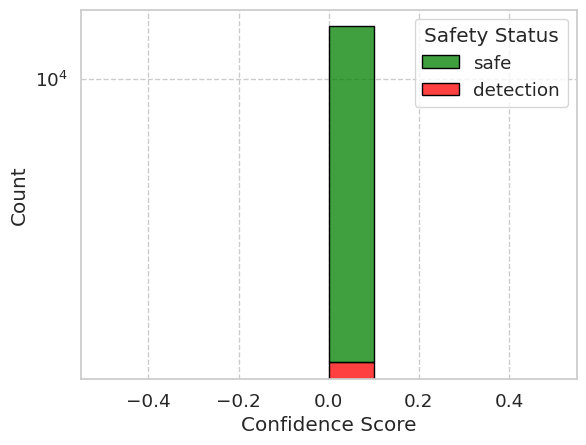

In [32]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

custom_color = {'detection': 'red', 'safe': 'green'}

ax = sns.histplot(data=result_df, x='prediction', hue='target', bins=10, multiple='stack', edgecolor='black', palette=custom_color)

plt.xlabel('Confidence Score')
plt.yscale('log')

ax.legend_.set_title('Safety Status')

Best Threshold: 0.000
Best F1 Score: 0.0000


Text(0, 0.5, 'Score')

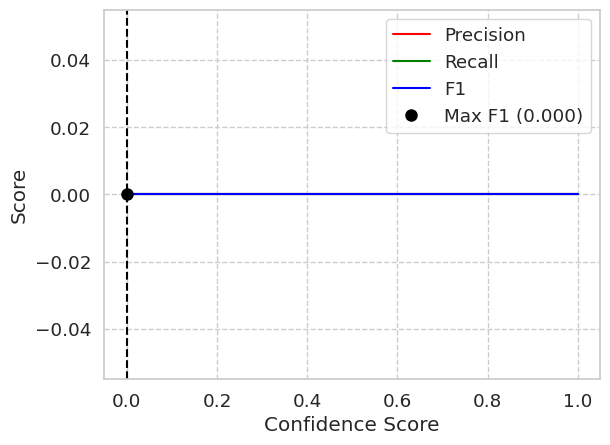

In [33]:
thr_val_arr = np.arange(0.0, 1.01, 0.01)

precision_arr = []
recall_arr = []
f1_arr = []

for thr_val in thr_val_arr:
    train_pred_binary = np.where(train_pred > thr_val, 1, 0)
    precision = precision_score(train_target, train_pred_binary, zero_division=0)
    recall = recall_score(train_target, train_pred_binary, zero_division=0)
    f1 = f1_score(train_target, train_pred_binary, zero_division=0)

    precision_arr.append(precision)
    recall_arr.append(recall)
    f1_arr.append(f1)

precision_arr = np.array(precision_arr)
recall_arr = np.array(recall_arr)
f1_arr = np.array(f1_arr)

sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(x=thr_val_arr, y=precision_arr, color='red', label='Precision')
sns.lineplot(x=thr_val_arr, y=recall_arr, color='green', label='Recall')
sns.lineplot(x=thr_val_arr, y=f1_arr, color='blue', label='F1')

best_f1_index = np.argmax(f1_arr)

train_best_threshold = thr_val_arr[best_f1_index]
best_f1_score = f1_arr[best_f1_index]

print(f"Best Threshold: {train_best_threshold:.3f}")
print(f"Best F1 Score: {best_f1_score:.4f}")

plt.axvline(x=train_best_threshold, color='black', linestyle='--')

plt.plot(train_best_threshold, best_f1_score, 'o', color='black', markersize=8,
         markeredgecolor='black', label=f'Max F1 ({best_f1_score:.3f})')

plt.legend()

plt.xlabel('Confidence Score')
plt.ylabel('Score')

([<matplotlib.axis.YTick at 0xfa2162e26850>,
 [Text(0, 0.5, 'Safe(0)'), Text(0, 1.5, 'Unsafe(1)')])

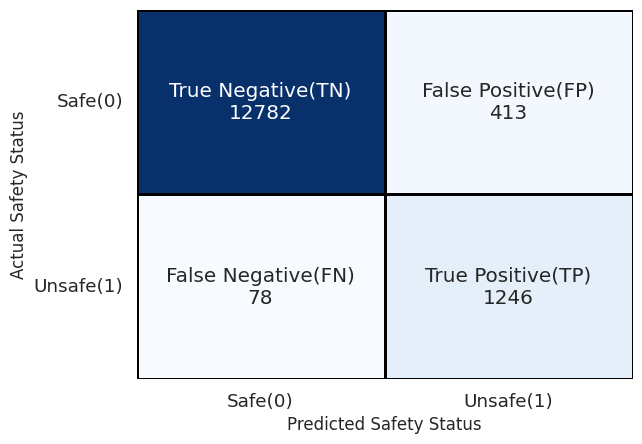

In [34]:
train_pred_binary = np.where(train_pred > train_best_threshold, 1, 0)

cm = confusion_matrix(train_target, train_pred_binary)

labels = np.array([[f'True Negative(TN)\n{cm[0, 0]}', f'False Positive(FP)\n{cm[0, 1]}'],
                   [f'False Negative(FN)\n{cm[1, 0]}', f'True Positive(TP)\n{cm[1, 1]}']])

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, linecolor='black', linewidths=1)

plt.ylabel('Actual Safety Status', fontsize=12)
plt.xlabel('Predicted Safety Status', fontsize=12)

plt.xticks([0.5, 1.5], ['Safe(0)', 'Unsafe(1)'])
plt.yticks([0.5, 1.5], ['Safe(0)', 'Unsafe(1)'], rotation=0, va='center')

In [35]:
print(precision_score(train_target, train_pred_binary))
print(recall_score(train_target, train_pred_binary))
print(f1_score(train_target, train_pred_binary))

0.7510548523206751
0.9410876132930514
0.8354006034193765


In [51]:
val_target_string = []

for val in val_target:
    if val == 1:
        val_target_string.append('detection')
    else:
        val_target_string.append('safe')

result_df = pd.concat([pd.DataFrame(val_pred, columns=['prediction']),
                       pd.DataFrame(val_target_string, columns=['target'])], axis=1)

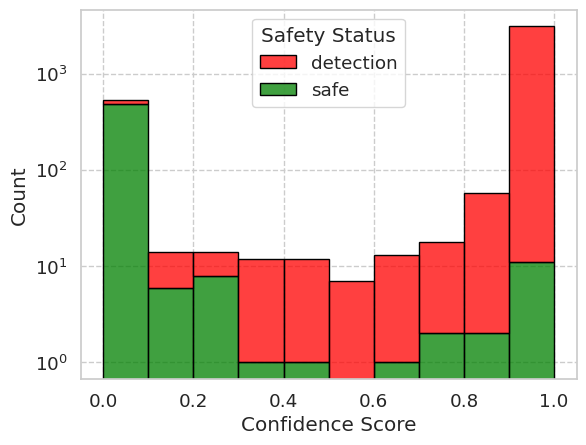

In [52]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

custom_color = {'detection': 'red', 'safe': 'green'}

ax = sns.histplot(data=result_df, x='prediction', hue='target', bins=10, multiple='stack', edgecolor='black', palette=custom_color)

plt.xlabel('Confidence Score')
plt.yscale('log')

ax.legend_.set_title('Safety Status')

Best Threshold: 0.040
Best F1 Score: 0.9892


Text(0, 0.5, 'Score')

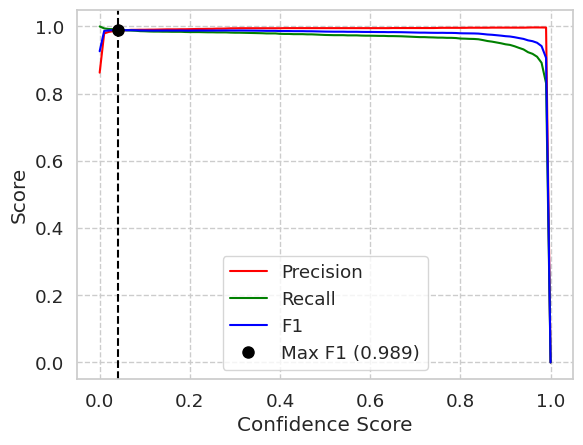

In [53]:
thr_val_arr = np.arange(0.0, 1.01, 0.01)

precision_arr = []
recall_arr = []
f1_arr = []

for thr_val in thr_val_arr:
    val_pred_binary = np.where(val_pred > thr_val, 1, 0)
    precision = precision_score(val_target, val_pred_binary, zero_division=0)
    recall = recall_score(val_target, val_pred_binary, zero_division=0)
    f1 = f1_score(val_target, val_pred_binary, zero_division=0)

    precision_arr.append(precision)
    recall_arr.append(recall)
    f1_arr.append(f1)

precision_arr = np.array(precision_arr)
recall_arr = np.array(recall_arr)
f1_arr = np.array(f1_arr)

sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(x=thr_val_arr, y=precision_arr, color='red', label='Precision')
sns.lineplot(x=thr_val_arr, y=recall_arr, color='green', label='Recall')
sns.lineplot(x=thr_val_arr, y=f1_arr, color='blue', label='F1')

best_f1_index = np.argmax(f1_arr)

best_threshold = thr_val_arr[best_f1_index]
best_f1_score = f1_arr[best_f1_index]

print(f"Best Threshold: {best_threshold:.3f}")
print(f"Best F1 Score: {best_f1_score:.4f}")

plt.axvline(x=best_threshold, color='black', linestyle='--')

plt.plot(best_threshold, best_f1_score, 'o', color='black', markersize=8,
         markeredgecolor='black', label=f'Max F1 ({best_f1_score:.3f})')

plt.legend()

plt.xlabel('Confidence Score')
plt.ylabel('Score')

([<matplotlib.axis.YTick at 0x71e864fbc990>,
 [Text(0, 0.5, 'Safe(0)'), Text(0, 1.5, 'Unsafe(1)')])

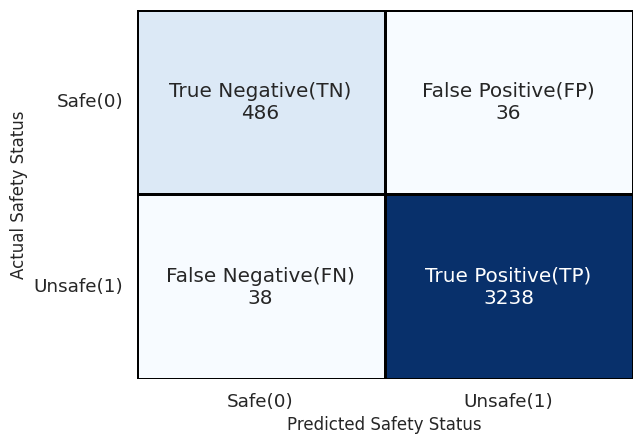

In [54]:
val_pred_binary = np.where(val_pred > train_best_threshold, 1, 0)

cm = confusion_matrix(val_target, val_pred_binary)

labels = np.array([[f'True Negative(TN)\n{cm[0, 0]}', f'False Positive(FP)\n{cm[0, 1]}'],
                   [f'False Negative(FN)\n{cm[1, 0]}', f'True Positive(TP)\n{cm[1, 1]}']])

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, linecolor='black', linewidths=1)

plt.ylabel('Actual Safety Status', fontsize=12)
plt.xlabel('Predicted Safety Status', fontsize=12)

plt.xticks([0.5, 1.5], ['Safe(0)', 'Unsafe(1)'])
plt.yticks([0.5, 1.5], ['Safe(0)', 'Unsafe(1)'], rotation=0, va='center')

In [55]:
print(precision_score(val_target, val_pred_binary))
print(recall_score(val_target, val_pred_binary))
print(f1_score(val_target, val_pred_binary))

0.9890042761148442
0.9884004884004884
0.9887022900763359
